---
title: Computer Vision <code>assignment-1</code>
descrption: Computer Vision Assignment-1
author: Poornima Bhatia
date: 'September 15, 2024'
categories: ['Impulse noise' , 'Gaussian noise' , 'Box filter' , 'Gaussian filter' , 'Median filter' , 'Canny Edge']
image: True
foramt:
html:
code-fold: true
---

# Introduction

### Prologue

Welcome to the Computer Vision Assignment Nagar (CVAN), where everyone has to solve some set of problems to go from location A to location B. There are total 5 places (A, B, C, D, E) in the CVAN with equally distributed rewards.
<br/><br/>
After visiting all the 5 places you will able to reach a glorious palce ResultPura (RP).
<br/><br/>
Prof. Shanmuganathan Raman is Time Variant Authority (TVA) of this universe, if found you copying the assignment or exam or any malpractice then instead of reaching ResultPura you will reach ZeroPura.
<br/><br/>
<b>Special fact about CVAN is you have to solve everything with some vision algorithm.</b>

### Task

You are currently at place A. Your task is to solve series of questions given below which will lead you to the final task of solving a JigSaw puzzle mystery. Someone has altered the reality of CVAN and makes changes in the vision algorithm of the brain and because of it everyone is now observing real world as jigsaw images in their vision and causing chaos in their daily life.
<br/><br/>
<b>Note: Only you can save them by not copying the assignment from others and but you can discuss with your friends.</b>

# Task

### Pre-defined code

In [1]:
# # Mounting google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Downloading all the required libraries

# Importing all the required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import style
from glob import glob
from natsort import natsorted
from tqdm import tqdm
style.use('ggplot')

In [2]:
# Loading all the images in the drive
gt_images = []

for files in tqdm(natsorted(glob('./images/A/*'))):
    gt_images.append(cv2.imread(files, 1))

gt_images = np.array(gt_images) # Only possible because all images are of same size

100%|██████████| 4/4 [00:00<00:00, 1377.10it/s]


In [3]:
def show_image_grid(images, M, N, title='Title'):
    # Assuming 'images' is a numpy array of shape (num_images, height, width, channels)
    fig, axes = plt.subplots(M, N, figsize=(N * 2, M * 2))

    if len(images.shape) < 4:
        images = np.expand_dims(images.copy(), axis=0)

    fig.suptitle(title)
    for i in range(M):
        for j in range(N):
            if M==1 and N==1:
                ax = axes
            elif M == 1 or N==1:
                ax = axes[max(i, j)]
            else:
                ax = axes[i, j]
            index = i * N + j
            if index < images.shape[0]:
                ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
            ax.axis('off')
    plt.tight_layout()
    plt.show()

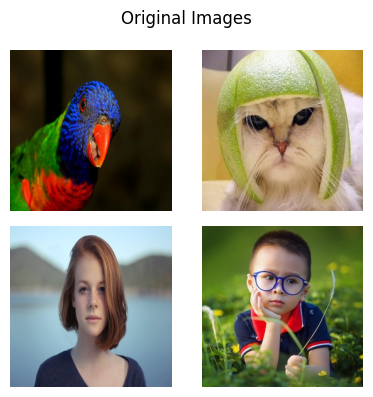

In [4]:
show_image_grid(gt_images, 2, 2, 'Original Images')

### Q1 [2 Marks]

Given some set of images, you have to add two different kind of noises to it.
* Impulse noise (Salt and Pepper noise)
* Gaussian noise

<br/>
<b>Note: Implement all the noise addition algorithm from scratch.</b> You can use numpy library for convolution and other methods.
<br/><br/>
Add noises in small amount so that not all the information in image is changes.
<br/><br/>
Also please vary the parameters of noise and display images accordingly.

In [5]:
def add_impulse_noise(image, noise_prob):
    # Write Your Code Here
    # copy image
    noisy_image = image.copy()

    # calculate number of salt and pepper pixels
    num_salt = int(np.ceil(noise_prob * image.size * 0.15))
    num_pepper = int(np.ceil(noise_prob * image.size * 0.15))

    # salt noise
    coords_salt = [np.random.randint(0, i, int(num_salt)) for i in image.shape[:2]]
    if image.ndim == 3: # for color images
        noisy_image[coords_salt[0], coords_salt[1], :] = 255 # max value for salt (white) (255 or 1)
    else: # for grayscale images
        noisy_image[coords_salt[0], coords_salt[1]] = 255 # max value for salt (white) (255 or 1)

    # pepper noise
    coords_pepper = [np.random.randint(0, i, int(num_pepper)) for i in image.shape[:2]]
    if image.ndim == 3: # for color images
        noisy_image[coords_pepper[0], coords_pepper[1], :] = 0 # min value for salt (black)
    else: # for grayscale images
        noisy_image[coords_pepper[0], coords_pepper[1]] = 0 # min value for pepper (black)

    return noisy_image

def add_gaussian_noise(image, mean, std):
    # Write Your Code Here
    gaussion_noise = np.random.normal(mean, std, image.shape)

    # add Gaussian noise to the image
    noisy_image = image + gaussion_noise

    # clip the values to be in the valid range for the image
    # assuming image is in 8-bit format (0-255).
    noisy_image = np.clip(noisy_image , 0 ,255).astype(np.uint8)

    return noisy_image

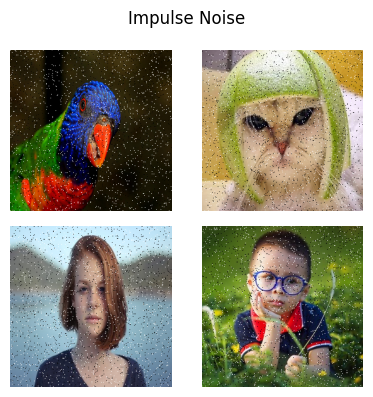

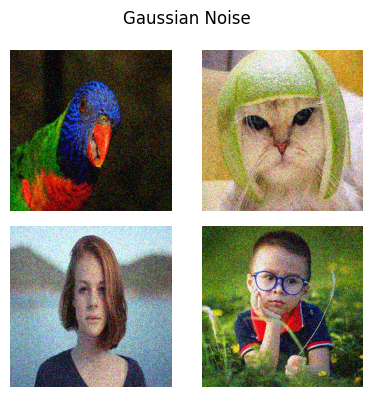

In [6]:
# Write code here
impulse_noisy_images  = []
gaussian_noisy_images = []

# Write code here for variation in noise parameter

for image in gt_images:
    impulse_noisy_images.append(add_impulse_noise(image, noise_prob=0.05))
    gaussian_noisy_images.append(add_gaussian_noise(image, mean=0., std=30))

impulse_noisy_images = np.array(impulse_noisy_images)
gaussian_noisy_images = np.array(gaussian_noisy_images)

show_image_grid(impulse_noisy_images, M=2, N=2, title='Impulse Noise')
show_image_grid(gaussian_noisy_images, M=2, N=2, title='Gaussian Noise')

### Q2 [3 Marks]

Use three different filtering operations and denoise the noisy images generated in the previous question. You have to use following noises value for this and rest of the question.
<pre>
noise_prob: 0.05 (impulse noise)
gaussian noise: mean = 0, std = 30
</pre>

* Box Filter: Moving Average Filter

[![boxfilter.webp](https://i.postimg.cc/4NtD4Z7k/boxfilter.webp)](https://postimg.cc/9rm816YJ)

* Gaussian Filter

[![gaussian.png](https://i.postimg.cc/Kvy9NTzw/gaussian.png)](https://postimg.cc/NLp7G5Rk)

* Median Filter

[![median.png](https://i.postimg.cc/q704Hqj5/median.png)](https://postimg.cc/NKNW1sh6)



<b>Note: Implement all the filters algorithm from scratch.</b> You can use numpy library for convolution and other methods.

In [7]:
def apply_box_filter(image, kernel_size):
    # Write Your Code Here
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
    pad_size = kernel_size // 2
    padded_image = np.pad(image, [(pad_size, pad_size), (pad_size, pad_size), (0, 0)], mode='constant')
    blurred_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the region of interest from the padded image
            region = padded_image[i:i+kernel_size, j:j+kernel_size, :]
            # Apply the box filter (average the values)
            blurred_image[i, j, :] = np.sum(region * kernel[:, :, np.newaxis], axis=(0, 1))

    return blurred_image

def apply_gaussain_filter(image, kernel_size, sigma):
    # Write Your Code Here
    def gaussian_kernel(kernel_size, sigma):
        kernel = np.fromfunction(lambda x, y: (1/(2*np.pi*sigma**2)) * np.exp(-((x-kernel_size//2)**2 + (y-kernel_size//2)**2) / (2*sigma**2)), (kernel_size, kernel_size))
        return kernel / np.sum(kernel)

    kernel = gaussian_kernel(kernel_size, sigma)

    # Pad the image with zeros to handle borders
    pad_size = kernel_size // 2
    padded_image = np.pad(image, [(pad_size, pad_size), (pad_size, pad_size), (0, 0)], mode='constant')

    # Initialize the output (blurred) image
    blurred_image = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the region of interest from the padded image
            region = padded_image[i:i+kernel_size, j:j+kernel_size, :]
            # Apply the Gaussian filter (weighted sum using the Gaussian kernel)
            blurred_image[i, j, :] = np.sum(region * kernel[:, :, np.newaxis], axis=(0, 1))

    return blurred_image

def apply_median_filter(image, kernel_size):
    # Write Your Code Here
    pad_size = kernel_size // 2
    padded_image = np.pad(image, [(pad_size, pad_size), (pad_size, pad_size), (0, 0)], mode='constant')
    filtered_image = np.zeros_like(image)

    # Apply the median filter
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            for c in range(image.shape[2]):  # Loop over color channels
                # Extract the neighborhood (region of interest) for the current pixel
                region = padded_image[i:i+kernel_size, j:j+kernel_size, c]

                # Flatten the region into a 1D array, then sort and find the median
                median_value = np.median(region)

                # Set the median value to the corresponding pixel in the output image
                filtered_image[i, j, c] = median_value

    return filtered_image


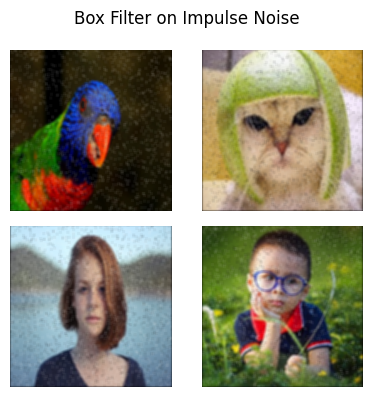

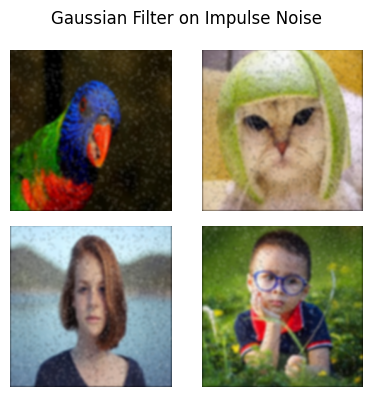

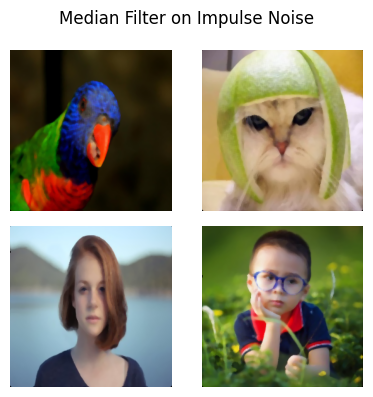

In [8]:
# Write code here

box_filter_images_impulse       = []
gaussian_filter_images_impulse  = []
median_filter_images_impulse    = []

for image in impulse_noisy_images:
    box_filter_images_impulse.append(apply_box_filter(image, kernel_size=5))
    gaussian_filter_images_impulse.append(apply_gaussain_filter(image, kernel_size=7, sigma=2.0))
    median_filter_images_impulse.append(apply_median_filter(image, kernel_size=5))

box_filter_images_impulse = np.array(box_filter_images_impulse)
gaussian_filter_images_impulse = np.array(gaussian_filter_images_impulse)
median_filter_images_impulse = np.array(median_filter_images_impulse)
show_image_grid(box_filter_images_impulse, M=2, N=2, title='Box Filter on Impulse Noise')
show_image_grid(gaussian_filter_images_impulse, M=2, N=2, title='Gaussian Filter on Impulse Noise')
show_image_grid(median_filter_images_impulse, M=2, N=2, title='Median Filter on Impulse Noise')

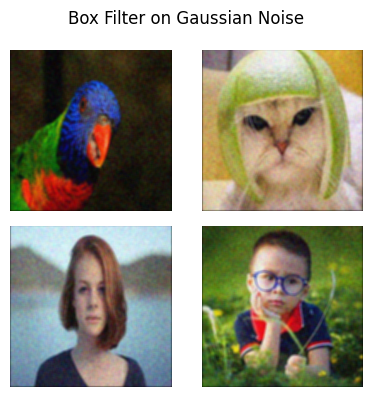

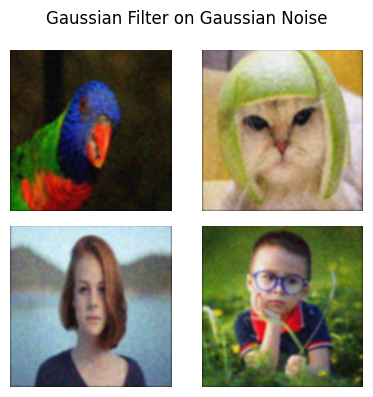

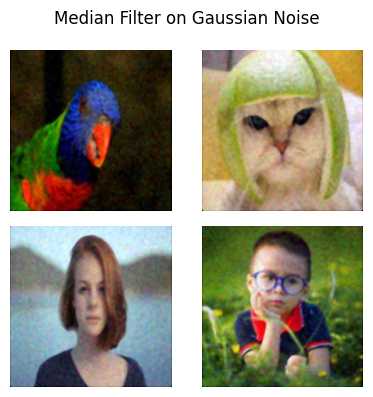

In [9]:
# Write code here
box_filter_images_gaussian       = []
gaussian_filter_images_gaussian  = []
median_filter_images_gaussian    = []

for image in gaussian_noisy_images:
    box_filter_images_gaussian.append(apply_box_filter(image, kernel_size=5))
    gaussian_filter_images_gaussian.append(apply_gaussain_filter(image, kernel_size=7, sigma=2.0))
    median_filter_images_gaussian.append(apply_median_filter(image, kernel_size=5))

box_filter_images_gaussian = np.array(box_filter_images_gaussian)
gaussian_filter_images_gaussian = np.array(gaussian_filter_images_gaussian)
median_filter_images_gaussian = np.array(median_filter_images_gaussian)

show_image_grid(box_filter_images_gaussian, M=2, N=2, title='Box Filter on Gaussian Noise')
show_image_grid(gaussian_filter_images_gaussian, M=2, N=2, title='Gaussian Filter on Gaussian Noise')
show_image_grid(median_filter_images_gaussian, M=2, N=2, title='Median Filter on Gaussian Noise')

### Q3 [5 Marks]

Implement the Canny Edge Detector algorithm from scratch, you can use numpy library for computation operation such as convolution or sliding windows.
<br/>
Show canny edge results on the following denoised images from previous question:
* box_filter_images_impulse: [4, 256, 256, 3]
* gaussian_filter_images_impulse: [4, 256, 256, 3]
* median_filter_images_impulse: [4, 256, 256, 3]
* box_filter_images_gaussian: [4, 256, 256, 3]
* gaussian_filter_images_gaussian: [4, 256, 256, 3]
* median_filter_images_gaussian: [4, 256, 256, 3]

Total number of images in each of above array is: 4 <br/>
Each is of size H: 256, W: 256 and Channels: 3 <br/><br/>
Compare your implementation with Opencv canny edge detector method.<br/><br/>
Create a table of 6 x 4 (where 6 is all the filters and 4 is number of images) and show Root Mean Square Error between your canny edge image and opencv canny edge image.

In [10]:
def apply_canny_edge_detector_opencv(image, threshold1, threshold2):

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply the Canny edge detector
    edges = cv2.Canny(gray_image, threshold1, threshold2)

    # This is done only for converting 1 channel image to 3 channels for
    # visualization purpose in matplotlib
    edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    return edges

def apply_canny_edge_detector_self(image, threshold1, threshold2):
    # Write your code here
    def to_grayscale(img: np.ndarray):
        R_COEF = 0.2989
        G_COEF = 0.5870
        B_COEF = 0.1140

        # Convert BGR image to grayscale
        b, g, r = img[..., 0], img[..., 1], img[..., 2]
        grayscale_image = B_COEF * b + G_COEF * g + R_COEF * r

        return grayscale_image

    def gaussian_kernel(kernel_size, sigma):
        kernel = np.fromfunction(lambda x, y: (1/(2*np.pi*sigma**2)) * np.exp(-((x-kernel_size//2)**2 + (y-kernel_size//2)**2) / (2*sigma**2)), (kernel_size, kernel_size))
        return kernel / np.sum(kernel)

    def convolve2d(image, kernel):
        img_h, img_w = image.shape[0] , image.shape[1]
        k_h, k_w = kernel.shape
        pad_h = k_h // 2
        pad_w = k_w // 2
        # Pad the image to handle borders
        if len(image.shape) == 2:  # Grayscale image
            padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
        else:  # Color image
            padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant', constant_values=0)
        if len(image.shape) == 2:  # Grayscale image
            output = np.zeros((img_h, img_w), dtype=np.float32)
        else:  # Color image
            output = np.zeros((img_h, img_w, image.shape[2]), dtype=np.float32)
        for i in range(img_h):
            for j in range(img_w):
                # Extract the region of interest
                region = padded_image[i:i+k_h, j:j+k_w]
                if len(image.shape) == 3:  # Color image
                    for c in range(image.shape[2]):
                        output[i, j, c] = np.sum(region[:, :, c] * kernel)
                else:  # Grayscale image
                    output[i, j] = np.sum(region * kernel)

        return output

    def apply_gaussian_blur(image, kernel_size, sigma):
        kernel = gaussian_kernel(kernel_size, sigma)
        return convolve2d(image, kernel)

    def sobel_filters(image):
        horizontal_filter = np.array([[-1, 0, 1],
                                      [-2, 0, 2],
                                      [-1, 0, 1]])
        vertical_filter = np.transpose(horizontal_filter)

        horizontal_gradient = convolve2d(image, horizontal_filter)
        vertical_gradient = convolve2d(image, vertical_filter)

        magnitude = np.sqrt(horizontal_gradient ** 2 + vertical_gradient ** 2)
        direction = np.arctan2(vertical_gradient, horizontal_gradient)
        return magnitude, direction

    def non_max_suppression(G, theta):
        M, N = G.shape
        Z = np.zeros((M, N), dtype=np.int32)  # resultant image
        angle = theta * 180.0 / np.pi  # max -> 180, min -> -180
        angle[angle < 0] += 180  # max -> 180, min -> 0

        for i in range(1, M - 1):
            for j in range(1, N - 1):
                q = 255
                r = 255

                if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                    r = G[i, j - 1]
                    q = G[i, j + 1]

                elif 22.5 <= angle[i, j] < 67.5:
                    r = G[i - 1, j + 1]
                    q = G[i + 1, j - 1]

                elif 67.5 <= angle[i, j] < 112.5:
                    r = G[i - 1, j]
                    q = G[i + 1, j]

                elif 112.5 <= angle[i, j] < 157.5:
                    r = G[i + 1, j + 1]
                    q = G[i - 1, j - 1]

                if (G[i, j] >= q) and (G[i, j] >= r):
                    Z[i, j] = G[i, j]
                else:
                    Z[i, j] = 0
        return Z

    def double_threshold(img, lowThreshold, highThreshold):
        M, N = img.shape
        res = np.zeros((M,N), dtype=np.int32)
        weak = 75
        strong = 255
        strong_i, strong_j = np.where(img >= highThreshold)
        # zeros_i, zeros_j = np.where(img < lowThreshold)
        weak_i, weak_j = np.where((img <= highThreshold) & (img >= lowThreshold))
        res[strong_i, strong_j] = strong
        res[weak_i, weak_j] = weak
        return res

    def hysteresis(img, weak, strong=255):
        M, N = img.shape

        for i in range(1, M-1):
            for j in range(1, N-1):
                if (img[i, j] == weak):
                    if (
                        (img[i+1, j-1] == strong) or (img[i+1, j] == strong) or
                        (img[i+1, j+1] == strong) or (img[i, j-1] == strong) or
                        (img[i, j+1] == strong) or (img[i-1, j-1] == strong) or
                        (img[i-1, j] == strong) or (img[i-1, j+1] == strong)
                    ):
                        img[i, j] = strong
                    else:
                        img[i, j] = 0
        return img

    kernel_size = 7
    sigma = 0.5
    low_threshold = threshold1
    high_threshold = threshold2
    # low_threshold = threshold1*0.30
    # high_threshold = threshold2*(1-0.30)

    # Convert to grayscale
    gray_image = to_grayscale(image)
    # Apply Gaussian Blur
    smoothed_image = apply_gaussian_blur(gray_image, kernel_size, sigma)

    # Compute Gradient Magnitude and Direction
    magnitude, direction = sobel_filters(smoothed_image)

    # Apply Non-Maximum Suppression
    non_max_suppressed = non_max_suppression(magnitude, direction)

    # Apply Double Thresholding
    connected_edges = double_threshold(non_max_suppressed, low_threshold, high_threshold)

    # Perform Edge Tracking by Hysteresis
    edges = hysteresis(connected_edges , weak = 75)

    # Convert to 8-bit image for visualization
    edges = np.uint8(edges)
    # This is done only for converting 1 channel image to 3 channels for
    # Convert to BGR for visualization in matplotlib
    edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    return edges
    # return gray_image , smoothed_image , non_max_suppressed , edges

In [11]:
threshold1 = 80
threshold2 = 180

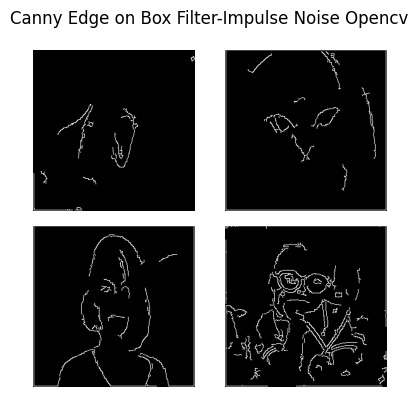

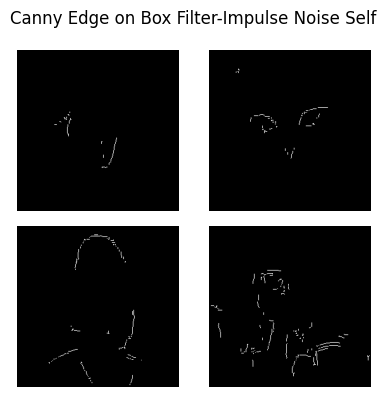

In [12]:
canny_edge_opencv_box_filter_images_impulse = []
canny_edge_self_box_filter_images_impulse = []

for image in box_filter_images_impulse:
    canny_edge_opencv_box_filter_images_impulse.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_box_filter_images_impulse.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_box_filter_images_impulse = np.array(canny_edge_opencv_box_filter_images_impulse)
canny_edge_self_box_filter_images_impulse = np.array(canny_edge_self_box_filter_images_impulse)

show_image_grid(canny_edge_opencv_box_filter_images_impulse, M=2, N=2, title='Canny Edge on Box Filter-Impulse Noise Opencv')
show_image_grid(canny_edge_self_box_filter_images_impulse, M=2, N=2, title='Canny Edge on Box Filter-Impulse Noise Self')

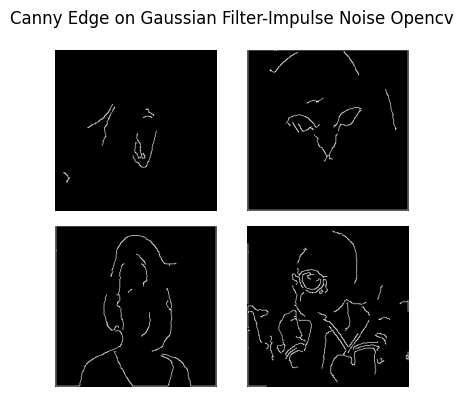

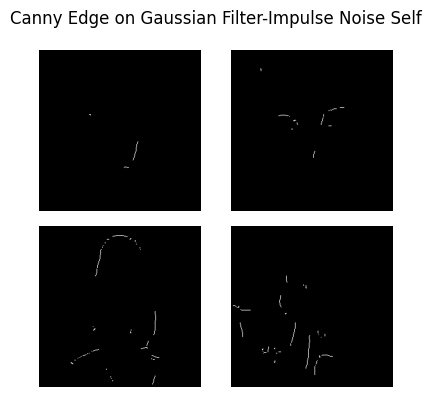

In [13]:
canny_edge_opencv_gaussian_filter_images_impulse = []
canny_edge_self_gaussian_filter_images_impulse = []

for image in gaussian_filter_images_impulse:
    canny_edge_opencv_gaussian_filter_images_impulse.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_gaussian_filter_images_impulse.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_gaussian_filter_images_impulse = np.array(canny_edge_opencv_gaussian_filter_images_impulse)
canny_edge_self_gaussian_filter_images_impulse = np.array(canny_edge_self_gaussian_filter_images_impulse)

show_image_grid(canny_edge_opencv_gaussian_filter_images_impulse, M=2, N=2, title='Canny Edge on Gaussian Filter-Impulse Noise Opencv')
show_image_grid(canny_edge_self_gaussian_filter_images_impulse, M=2, N=2, title='Canny Edge on Gaussian Filter-Impulse Noise Self')

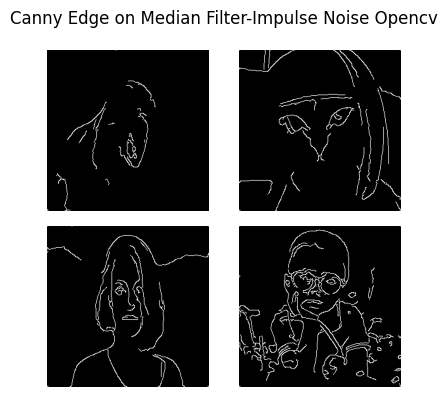

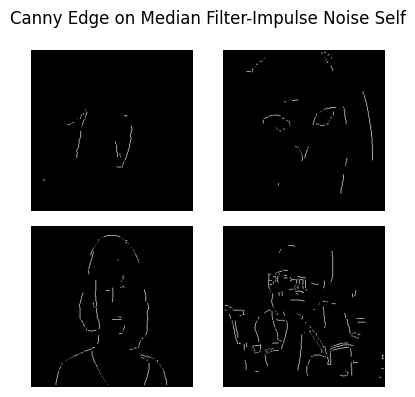

In [14]:
canny_edge_opencv_median_filter_images_impulse = []
canny_edge_self_median_filter_images_impulse = []

for image in median_filter_images_impulse:
    canny_edge_opencv_median_filter_images_impulse.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_median_filter_images_impulse.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_median_filter_images_impulse = np.array(canny_edge_opencv_median_filter_images_impulse)
canny_edge_self_median_filter_images_impulse = np.array(canny_edge_self_median_filter_images_impulse)

show_image_grid(canny_edge_opencv_median_filter_images_impulse, M=2, N=2, title='Canny Edge on Median Filter-Impulse Noise Opencv')
show_image_grid(canny_edge_self_median_filter_images_impulse, M=2, N=2, title='Canny Edge on Median Filter-Impulse Noise Self')

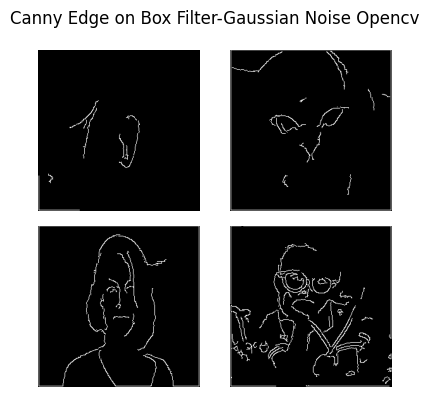

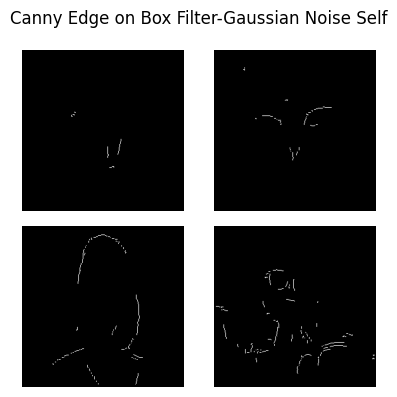

In [15]:
canny_edge_opencv_box_filter_images_gaussian = []
canny_edge_self_box_filter_images_gaussian = []

for image in box_filter_images_gaussian:
    canny_edge_opencv_box_filter_images_gaussian.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_box_filter_images_gaussian.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_box_filter_images_gaussian = np.array(canny_edge_opencv_box_filter_images_gaussian)
canny_edge_self_box_filter_images_gaussian = np.array(canny_edge_self_box_filter_images_gaussian)

show_image_grid(canny_edge_opencv_box_filter_images_gaussian, M=2, N=2, title='Canny Edge on Box Filter-Gaussian Noise Opencv')
show_image_grid(canny_edge_self_box_filter_images_gaussian, M=2, N=2, title='Canny Edge on Box Filter-Gaussian Noise Self')

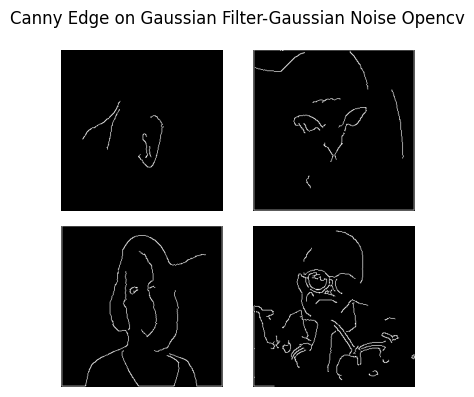

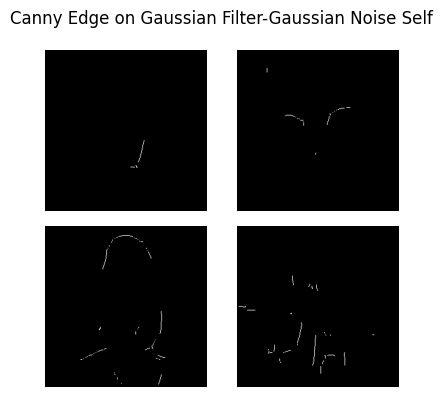

In [16]:
canny_edge_opencv_gaussian_filter_images_gaussian = []
canny_edge_self_gaussian_filter_images_gaussian = []

for image in gaussian_filter_images_gaussian:
    canny_edge_opencv_gaussian_filter_images_gaussian.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_gaussian_filter_images_gaussian.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_gaussian_filter_images_gaussian = np.array(canny_edge_opencv_gaussian_filter_images_gaussian)
canny_edge_self_gaussian_filter_images_gaussian = np.array(canny_edge_self_gaussian_filter_images_gaussian)

show_image_grid(canny_edge_opencv_gaussian_filter_images_gaussian, M=2, N=2, title='Canny Edge on Gaussian Filter-Gaussian Noise Opencv')
show_image_grid(canny_edge_self_gaussian_filter_images_gaussian, M=2, N=2, title='Canny Edge on Gaussian Filter-Gaussian Noise Self')

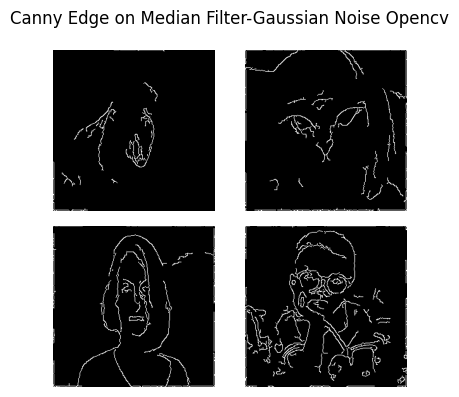

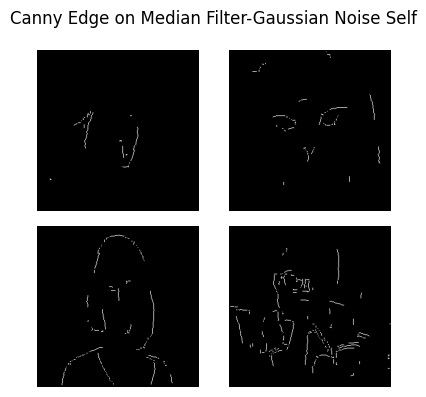

In [17]:
canny_edge_opencv_median_filter_images_gaussian = []
canny_edge_self_median_filter_images_gaussian = []

for image in median_filter_images_gaussian:
    canny_edge_opencv_median_filter_images_gaussian.append(apply_canny_edge_detector_opencv(image, threshold1=threshold1, threshold2=threshold2))
    canny_edge_self_median_filter_images_gaussian.append(apply_canny_edge_detector_self(image, threshold1=threshold1, threshold2=threshold2))

canny_edge_opencv_median_filter_images_gaussian = np.array(canny_edge_opencv_median_filter_images_gaussian)
canny_edge_self_median_filter_images_gaussian = np.array(canny_edge_self_median_filter_images_gaussian)

show_image_grid(canny_edge_opencv_median_filter_images_gaussian, M=2, N=2, title='Canny Edge on Median Filter-Gaussian Noise Opencv')
show_image_grid(canny_edge_self_median_filter_images_gaussian, M=2, N=2, title='Canny Edge on Median Filter-Gaussian Noise Self')

In [18]:
####
# RMSE table of size 6 x 4
###
def calculate_rmse(image1, image2):
    # Convert images to grayscale if they're not already
    gray_image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray_image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # Compute the RMSE
    mse = np.mean((gray_image1 - gray_image2) ** 2)
    rmse = np.sqrt(mse)
    return rmse
rmse_table = np.zeros((6, 4))

def compute_rmse_for_images(image_set, filter_index, rmse_table):
    for i, image in enumerate(image_set):
        opencv_edge = apply_canny_edge_detector_opencv(image, threshold1, threshold2)
        self_edge = apply_canny_edge_detector_self(image, threshold1, threshold2)
        rmse_table[filter_index, i] = calculate_rmse(opencv_edge, self_edge)

# Compute RMSE for all filter sets
compute_rmse_for_images(box_filter_images_impulse, 0, rmse_table)
compute_rmse_for_images(gaussian_filter_images_impulse, 1, rmse_table)
compute_rmse_for_images(median_filter_images_impulse, 2, rmse_table)
compute_rmse_for_images(box_filter_images_gaussian, 3, rmse_table)
compute_rmse_for_images(gaussian_filter_images_gaussian, 4, rmse_table)
compute_rmse_for_images(median_filter_images_gaussian, 5, rmse_table)

print("RMSE Table (6 x 4):")
print(rmse_table)

RMSE Table (6 x 4):
[[0.10633326 0.1682864  0.17819523 0.23927176]
 [0.07783148 0.15814283 0.16724043 0.18786585]
 [0.10510644 0.1643877  0.14537339 0.21406107]
 [0.08924734 0.16535946 0.17681985 0.23053495]
 [0.07503661 0.16415548 0.1711633  0.18204969]
 [0.12566959 0.18664355 0.1860704  0.23872909]]
